# Training Results

Loss curves, in-loop LFW accuracy, and a t-SNE projection of validation embeddings from the best checkpoint.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
hist = json.loads((ROOT / 'training_pipeline/checkpoints/history.json').read_text())
print(f'Epochs run:        {len(hist["train_loss"])}')
print(f'Final train loss:  {hist["train_loss"][-1]:.4f}')
print(f'Best LFW acc:      {max(hist["lfw_acc"]):.4f}')

Epochs run:        20
Final train loss:  0.1407
Best LFW acc:      0.9760


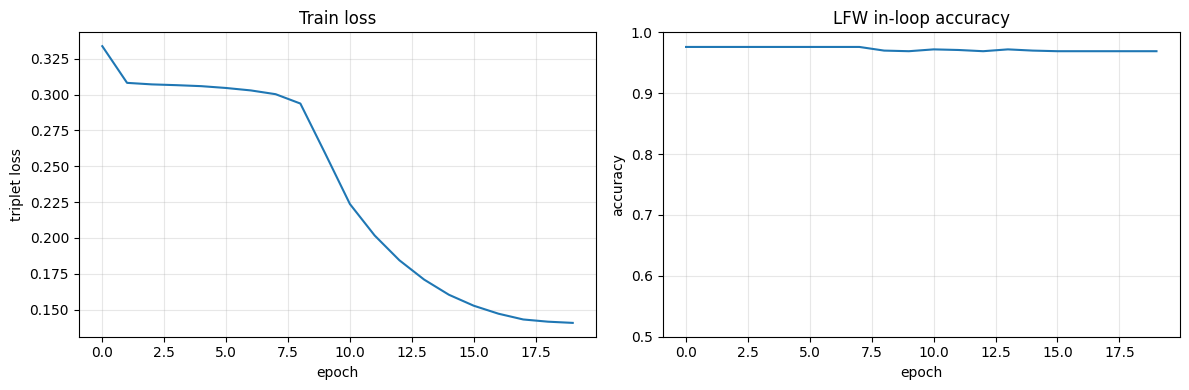

In [2]:
fig, (a, b) = plt.subplots(1, 2, figsize=(12, 4))
a.plot(hist['train_loss'])
a.set_title('Train loss')
a.set_xlabel('epoch')
a.set_ylabel('triplet loss')
a.grid(True, alpha=0.3)
b.plot(hist['lfw_acc'])
b.set_title('LFW in-loop accuracy')
b.set_xlabel('epoch')
b.set_ylabel('accuracy')
b.set_ylim(0.5, 1.0)
b.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

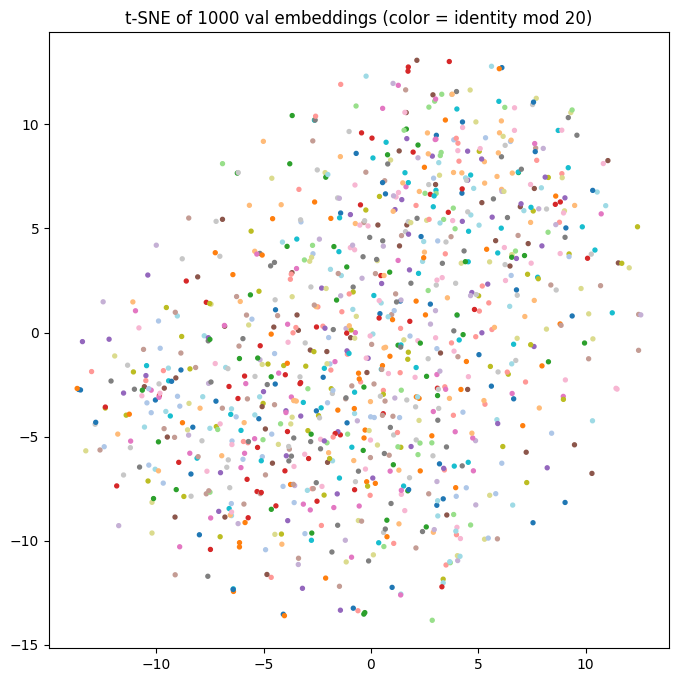

In [3]:
import sys
sys.path.insert(0, str(ROOT))

import torch
import numpy as np
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader
from training_pipeline.src.dataset import FaceDataset, eval_transform
from training_pipeline.src.model import FaceEmbedding

ckpt = torch.load(ROOT / 'training_pipeline/checkpoints/best.pt', map_location='cpu')
model = FaceEmbedding(embedding_dim=ckpt['cfg']['train']['embedding_dim'], pretrained=False)
model.load_state_dict(ckpt['model'])
model.eval()

ds = FaceDataset(ROOT / 'process-data/manifest.parquet', split='val', transform=eval_transform())
n_sample = min(1000, len(ds))
idxs = np.random.RandomState(0).choice(len(ds), size=n_sample, replace=False)
imgs = torch.stack([ds[i][0] for i in idxs])
labels = np.array([ds[i][1] for i in idxs])

with torch.no_grad():
    emb = model(imgs).cpu().numpy()

z = TSNE(n_components=2, random_state=0, perplexity=30, init='pca').fit_transform(emb)
plt.figure(figsize=(8, 8))
plt.scatter(z[:, 0], z[:, 1], c=labels % 20, s=8, cmap='tab20')
plt.title(f't-SNE of {n_sample} val embeddings (color = identity mod 20)')
plt.show()

In [4]:
# Hyperparameters used.
cfg = ckpt['cfg']
tbl = {**cfg['train'], 'eval_max_pairs_inloop': cfg['eval']['max_pairs_inloop']}
import pandas as pd
pd.DataFrame(tbl.items(), columns=['param', 'value'])

,param,value
0,epochs,20.00000
1,p,32.00000
2,k,4.00000
3,batches_per_epoch,1500.00000
4,margin,0.30000
5,lr_head,0.00030
6,lr_backbone,0.00003
7,weight_decay,0.00010
8,warmup_steps,500.00000
9,num_workers,8.00000
